<a href="https://colab.research.google.com/github/MuhammadShofiyyurrohman/machine-learning/blob/main/praktikum11Mandiri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/praktikum_ml/praktikum11/data/database.csv')
df.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


In [9]:
df.columns

Index(['Date', 'Time', 'Latitude', 'Longitude', 'Type', 'Depth', 'Depth Error',
       'Depth Seismic Stations', 'Magnitude', 'Magnitude Type',
       'Magnitude Error', 'Magnitude Seismic Stations', 'Azimuthal Gap',
       'Horizontal Distance', 'Horizontal Error', 'Root Mean Square', 'ID',
       'Source', 'Location Source', 'Magnitude Source', 'Status'],
      dtype='object')

In [10]:
gps = df[['Latitude', 'Longitude']].dropna()

gps.shape


(23412, 2)

In [11]:
gps = gps.sample(20000, random_state=42)   # Ambil 20 ribu data saja


In [12]:
scaler = StandardScaler()
gps_scaled = scaler.fit_transform(gps)


In [13]:
db = DBSCAN(eps=0.3, min_samples=10).fit(gps_scaled)
labels = db.labels_

gps['cluster'] = labels


In [14]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("Jumlah Cluster:", n_clusters)
print("Jumlah Noise:", n_noise)


Jumlah Cluster: 2
Jumlah Noise: 4


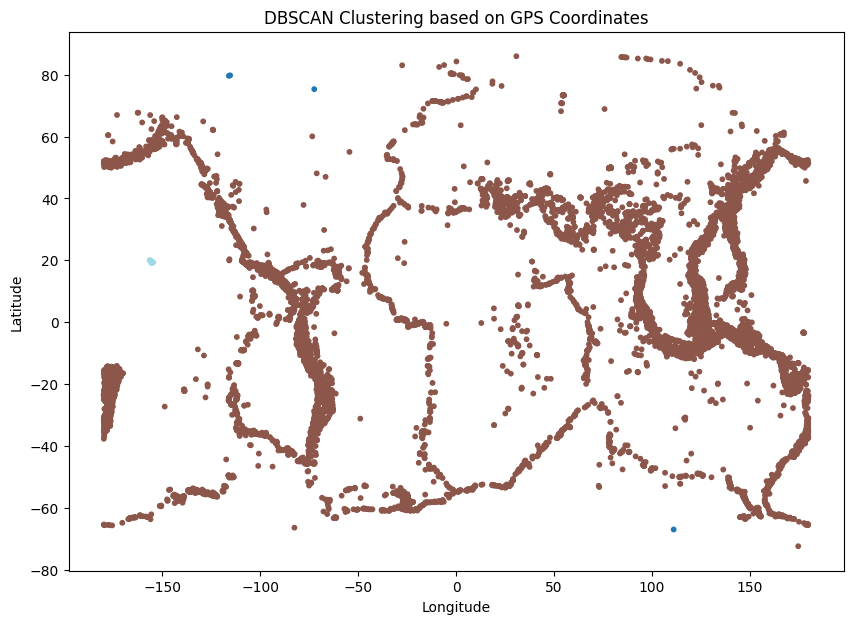

In [15]:
plt.figure(figsize=(10, 7))
plt.scatter(gps['Longitude'], gps['Latitude'],
            c=gps['cluster'], cmap='tab20', s=10)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("DBSCAN Clustering based on GPS Coordinates")
plt.show()


In [16]:
!pip install folium
import folium

m = folium.Map(location=[0, 0], zoom_start=2)

for i, row in gps.sample(3000).iterrows():  # Kurangi sampel agar ringan
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=2,
        color='red' if row['cluster'] == -1 else 'blue',
        fill=True
    ).add_to(m)

m
